In [1]:
import tensorflow as tf

In [2]:
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
(X_train,y_train), (X_test,y_test) = keras.datasets.mnist.load_data()

In [4]:
len(X_train)

60000

In [5]:
len(X_test)

10000

In [6]:
X_train[0].shape

(28, 28)

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

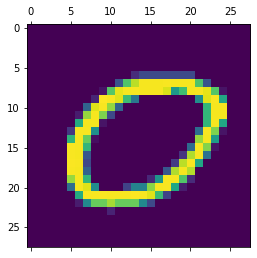

In [8]:
plt.matshow(X_train[156])

In [9]:
y_train[156]

0

In [10]:
X_train =X_train/255
X_test =X_test/255


In [11]:
X_train_flattened = X_train.reshape(len(X_train),28*28)

In [12]:
X_train_flattened.shape

(60000, 784)

In [13]:
X_test_flattened = X_test.reshape(len(X_test),28*28)

In [14]:
X_test_flattened.shape

(10000, 784)

In [15]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [16]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4699 - accuracy: 0.8774
Epoch 2/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3041 - accuracy: 0.9141
Epoch 3/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2836 - accuracy: 0.9212
Epoch 4/5
1875/1875 [==============================] - 2s 989us/step - loss: 0.2732 - accuracy: 0.9238
Epoch 5/5
1875/1875 [==============================] - 2s 991us/step - loss: 0.2666 - accuracy: 0.9253


In [17]:
model.evaluate(X_test_flattened,y_test)

313/313 [==============================] - 0s 773us/step - loss: 0.2670 - accuracy: 0.9256


[0.26701128482818604, 0.925599992275238]

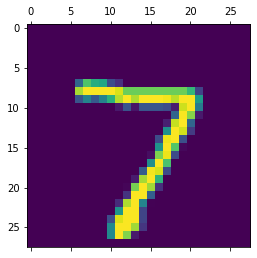

In [18]:
plt.matshow(X_test[0])

In [19]:
y_pred = model.predict(X_test_flattened)
y_pred[0]

array([1.6038984e-02, 3.7304451e-07, 8.7458789e-02, 9.5555413e-01,
       2.7101040e-03, 1.0177660e-01, 1.1409645e-06, 9.9973381e-01,
       1.0913044e-01, 6.5167433e-01], dtype=float32)

In [20]:
np.argmax(y_pred[0])

7

In [21]:
y_predicted_labels = [np.argmax(i) for i in y_pred]
y_predicted_labels[:5]

[7, 2, 1, 0, 4]

In [22]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [23]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)

In [24]:
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 952,    0,    4,    3,    0,    5,    9,    2,    3,    2],
       [   0, 1112,    4,    2,    0,    1,    4,    2,   10,    0],
       [   3,    9,  947,   14,    8,    2,   10,    8,   27,    4],
       [   0,    0,   25,  930,    1,   14,    2,    8,   19,   11],
       [   1,    1,    9,    2,  917,    0,    8,    3,    9,   32],
       [   9,    3,    6,   45,   12,  749,   15,    6,   38,    9],
       [   7,    3,    8,    1,    7,   10,  917,    2,    3,    0],
       [   1,    5,   26,    7,    9,    0,    0,  940,    2,   38],
       [   4,    8,    9,   22,    9,   17,    9,   12,  875,    9],
       [   7,    7,    2,   11,   34,    4,    0,   18,    9,  917]])>

Text(69.0, 0.5, 'Truth')

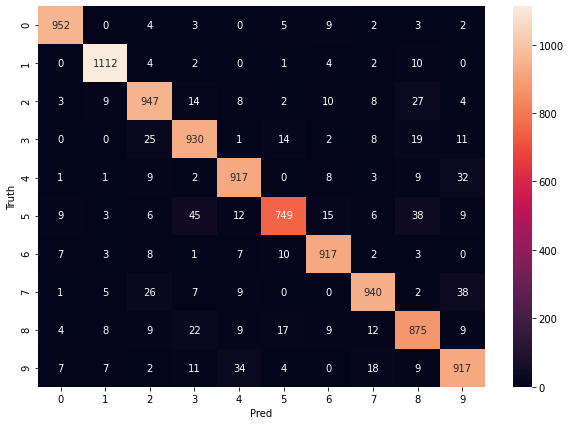

In [25]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Pred')
plt.ylabel("Truth")

In [26]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid'),
    
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2672 - accuracy: 0.9243
Epoch 2/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.1192 - accuracy: 0.9646
Epoch 3/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0834 - accuracy: 0.9751
Epoch 4/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0640 - accuracy: 0.9805
Epoch 5/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.0505 - accuracy: 0.9840


In [28]:
model.evaluate(X_test_flattened,y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.0774 - accuracy: 0.9769


[0.07740438729524612, 0.9768999814987183]

Text(69.0, 0.5, 'Truth')

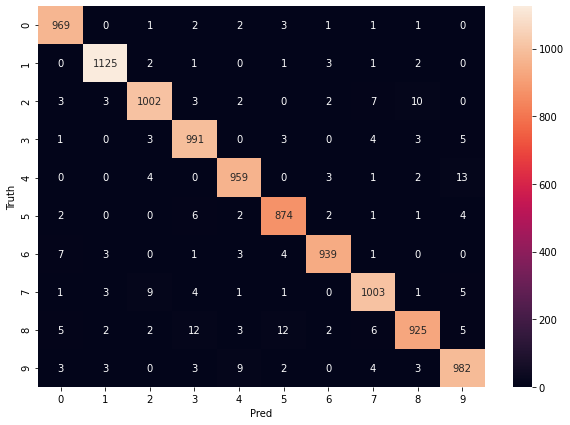

In [29]:
y_pred = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_pred]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Pred')
plt.ylabel("Truth")